In [1]:
from google.colab import files
files = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


# 1. Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


trade = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [4]:
trade.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [20]:
sentiment.head(20)

,timestamp,value,classification,date,Date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05
5,1517895000,8,Extreme Fear,2018-02-06,2018-02-06
6,1517981400,36,Fear,2018-02-07,2018-02-07
7,1518067800,30,Fear,2018-02-08,2018-02-08
8,1518154200,44,Fear,2018-02-09,2018-02-09
9,1518240600,54,Neutral,2018-02-10,2018-02-10


# 2. Data Cleaning

In [11]:

trade['Timestamp IST'] = pd.to_datetime(trade['Timestamp IST'], dayfirst=True)


sentiment['date'] = sentiment['date'].astype(str).str.strip()
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True, errors='coerce')


sentiment = sentiment.dropna(subset=['date'])

In [13]:
trade['Date'] = trade['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

# 3. Merge Both datasets

In [15]:
df = pd.merge(trade, sentiment, on='Date')

# 4. Feature Engineeering

In [16]:
df['profit_flag'] = df['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

# 5. Core Analysis

In [17]:
print("Average PnL by sentiment:\n", df.groupby('classification')['Closed PnL'].mean())
print("\nWin rate by sentiment:\n", df.groupby('classification')['profit_flag'].mean())
print("\nTrade count by sentiment:\n", df['classification'].value_counts())

Average PnL by sentiment:
 classification
Extreme Fear      26.578119
Extreme Greed    120.893258
Fear              86.681258
Greed             78.677868
Neutral           41.957142
Name: Closed PnL, dtype: float64

Win rate by sentiment:
 classification
Extreme Fear     0.354846
Extreme Greed    0.528253
Fear             0.456518
Greed            0.361139
Neutral          0.407882
Name: profit_flag, dtype: float64

Trade count by sentiment:
 classification
Fear             28391
Extreme Fear     18315
Greed            13103
Extreme Greed    11220
Neutral           8196
Name: count, dtype: int64


In [21]:
print("Average trade size by sentiment:\n",
df.groupby('classification')['Size USD'].mean())

Average trade size by sentiment:
 classification
Extreme Fear     5646.396075
Extreme Greed    2706.635852
Fear             7908.681044
Greed            4733.657064
Neutral          5186.895612
Name: Size USD, dtype: float64


# 6. Data Visulaization

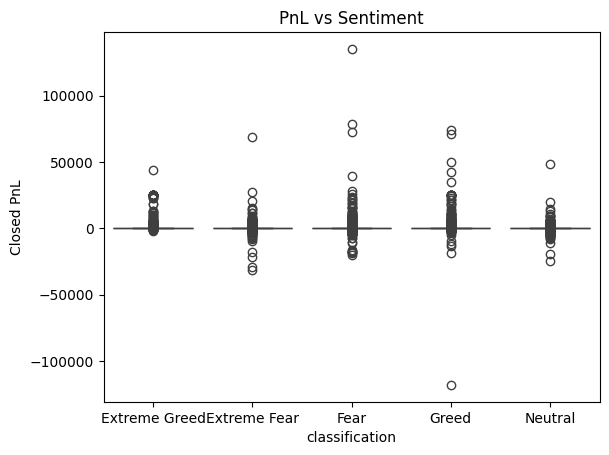

In [18]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL vs Sentiment")
plt.show()

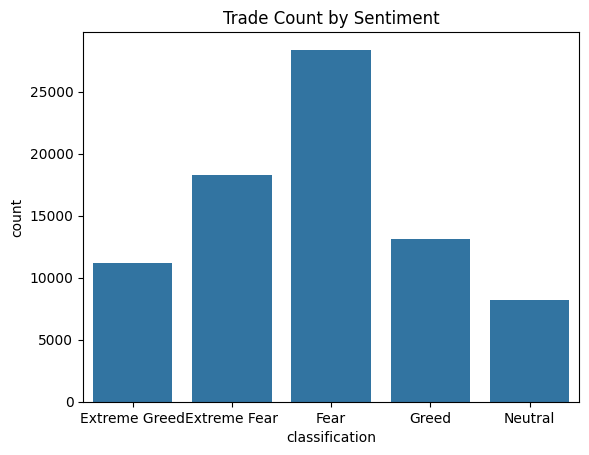

In [19]:
sns.countplot(x='classification', data=df)
plt.title("Trade Count by Sentiment")
plt.show()

# Final Insights

# Trader Behavior vs Market Sentiment

###

1. Trading activity is highest during Fear conditions, indicating that uncertainty in the market drives increased participation as traders attempt to capitalize on volatility.

2. Trader profitability is highest during Extreme Greed and lowest during Extreme Fear. This suggests that positive market sentiment leads to better trading outcomes, while panic-driven markets reduce performance.

3. Win rates follow a similar trend, with the highest success rate observed during Extreme Greed and the lowest during Extreme Fear. This highlights the strong influence of market sentiment on decision-making and trade success.

4. Average trade size is highest during Fear conditions, indicating that traders take larger and riskier positions during uncertain markets, likely driven by emotional reactions.

5. In contrast, trade sizes are lowest during Extreme Greed, despite achieving the highest profitability and win rates. This suggests that traders make more controlled, efficient, and disciplined decisions in positive market conditions.

6. Overall, the analysis shows that emotional trading during Fear leads to higher risk-taking but poorer performance, while rational behavior during Greed leads to more consistent and profitable outcomes.